# NSL-KDD Network Intrusion Detection System
## Complete Machine Learning Pipeline

**Dataset:** NSL-KDD (Network Security Laboratory – Knowledge Discovery in Databases)  
**Task:** Multi-class Network Intrusion Detection (Normal / DoS / Probe / R2L / U2R)  
**Models:** Gradient Boosting · Random Forest · Decision Tree · KNN · Logistic Regression · Naive Bayes




In [2]:
# ── Cell 1: Imports & Setup ──────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## Step 1 — Column Definitions & Attack Mapping

In [3]:
# ── Cell 2: Column Definitions ──────────────────────────
COLUMNS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

CATEGORICAL = ['protocol_type', 'service', 'flag']

# 39 attack types → 5 categories
ATTACK_MAP = {
    'normal': 'Normal',
    # DoS — Denial of Service
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','apache2':'DoS','udpstorm':'DoS','processtable':'DoS','worm':'DoS',
    # Probe — Surveillance / Port Scanning
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    # R2L — Remote to Local
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpgetattack':'R2L','snmpguess':'R2L',
    'xlock':'R2L','xsnoop':'R2L','httptunnel':'R2L',
    # U2R — User to Root
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'ps':'U2R','sqlattack':'U2R','xterm':'U2R',
}

print(f"Total columns defined : {len(COLUMNS)}")
print(f"Feature columns       : {len(COLUMNS) - 2}  (excl. label & difficulty)")
print(f"Categorical features  : {CATEGORICAL}")
print(f"Attack types mapped   : {len(ATTACK_MAP)}")


Total columns defined : 43
Feature columns       : 41  (excl. label & difficulty)
Categorical features  : ['protocol_type', 'service', 'flag']
Attack types mapped   : 39


## Step 2 — Data Loading / Synthetic Generator

In [31]:
# ── Cell 3: Synthetic NSL-KDD Generator ─────────────────

df=pd.read_csv('/content/kdd_train.csv', names=COLUMNS)



In [13]:
import pandas as pd

# ── Cell 4: Load Dataset ─────────────────────────────────
# ─────────────────────────────────────────────────────────
# Option A — Synthetic (runs immediately, no download needed)
# df = generate_synthetic_nslkdd(n=15000)

# Option B — Real NSL-KDD (uncomment after downloading)
df = pd.read_csv('/content/kdd_train.csv', names=COLUMNS, skiprows=1)
# ─────────────────────────────────────────────────────────

# Convert relevant columns to numeric after loading
numeric_cols = ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
                'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted',
                'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
                'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
                'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
                'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
                'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
                'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
                'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
                'dst_host_serror_rate', 'dst_host_srv_serror_rate',
                'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Dataset shape : {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
df.head()

Dataset shape : (125973, 43)

Label distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,NaN
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,NaN
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,NaN
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,NaN
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,NaN


## Step 3 — Exploratory Data Analysis (EDA)

In [9]:
# ── Cell 5: Basic EDA ────────────────────────────────────
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
print(f"Shape        : {df.shape}")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"Duplicates   : {df.duplicated().sum()}")
print(f"\nDtypes:")
print(df.dtypes.value_counts())
print(f"\nNumerical summary:")
df.describe().T[['mean','std','min','max']].round(3)


DATASET INFO
Shape        : (125974, 43)
Missing vals : 125974
Duplicates   : 0

Dtypes:
object     42
float64     1
Name: count, dtype: int64

Numerical summary:


,mean,std,min,max
difficulty,NaN,NaN,NaN,NaN


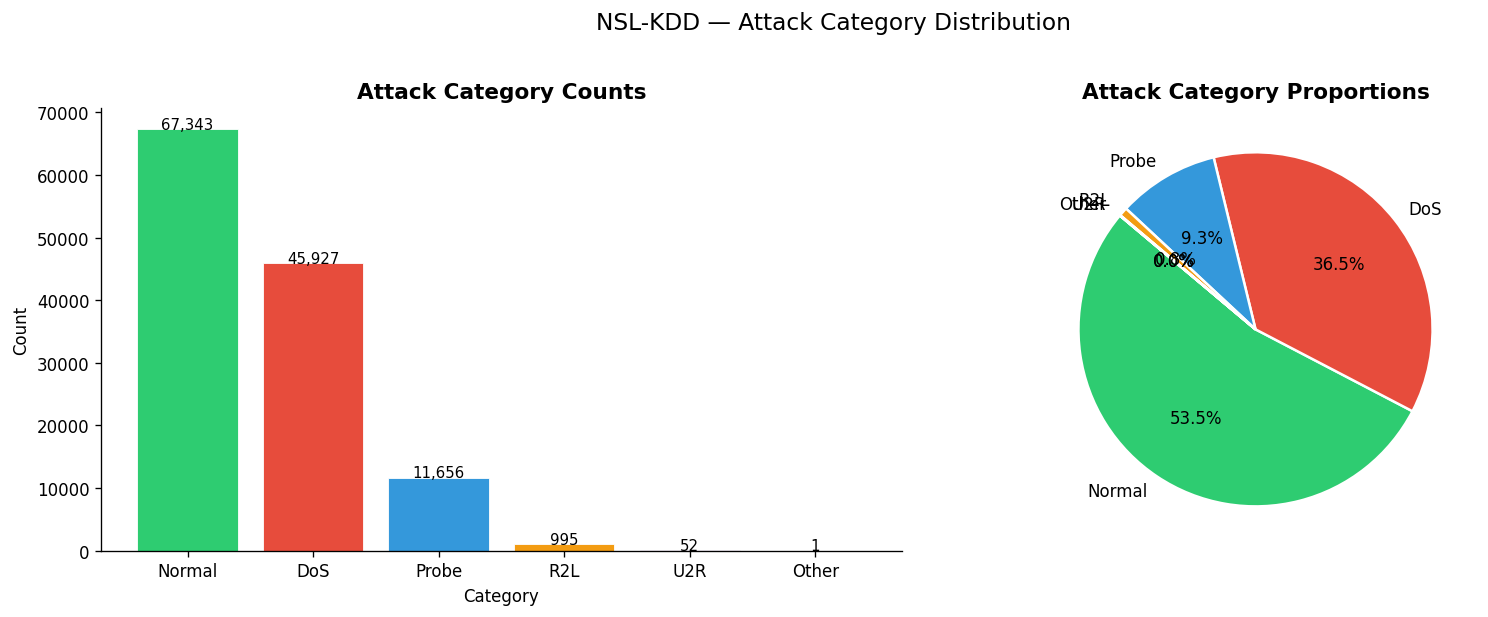

In [10]:
# ── Cell 6: Attack Category Distribution ─────────────────
df['attack_cat'] = df['label'].str.strip().str.lower().map(ATTACK_MAP).fillna('Other')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_counts = df['attack_cat'].value_counts()

axes[0].bar(cat_counts.index, cat_counts.values, color=COLORS[:len(cat_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Attack Category Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=COLORS[:len(cat_counts)], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Attack Category Proportions', fontsize=13, fontweight='bold')

plt.suptitle('NSL-KDD — Attack Category Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


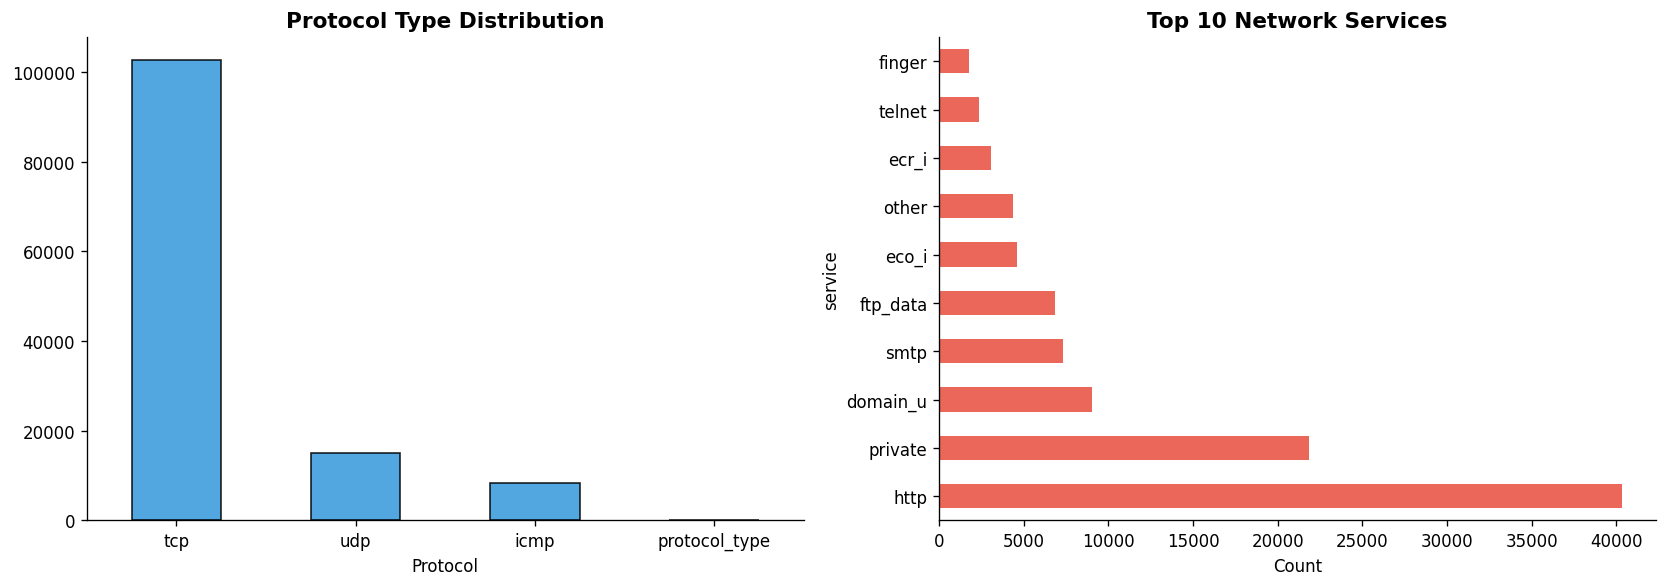

In [11]:
# ── Cell 7: Protocol & Service Analysis ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['protocol_type'].value_counts().plot(kind='bar', ax=axes[0],
    color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Protocol Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Protocol')
axes[0].tick_params(axis='x', rotation=0)

top_svc = df['service'].value_counts().head(10)
top_svc.plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.85)
axes[1].set_title('Top 10 Network Services', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


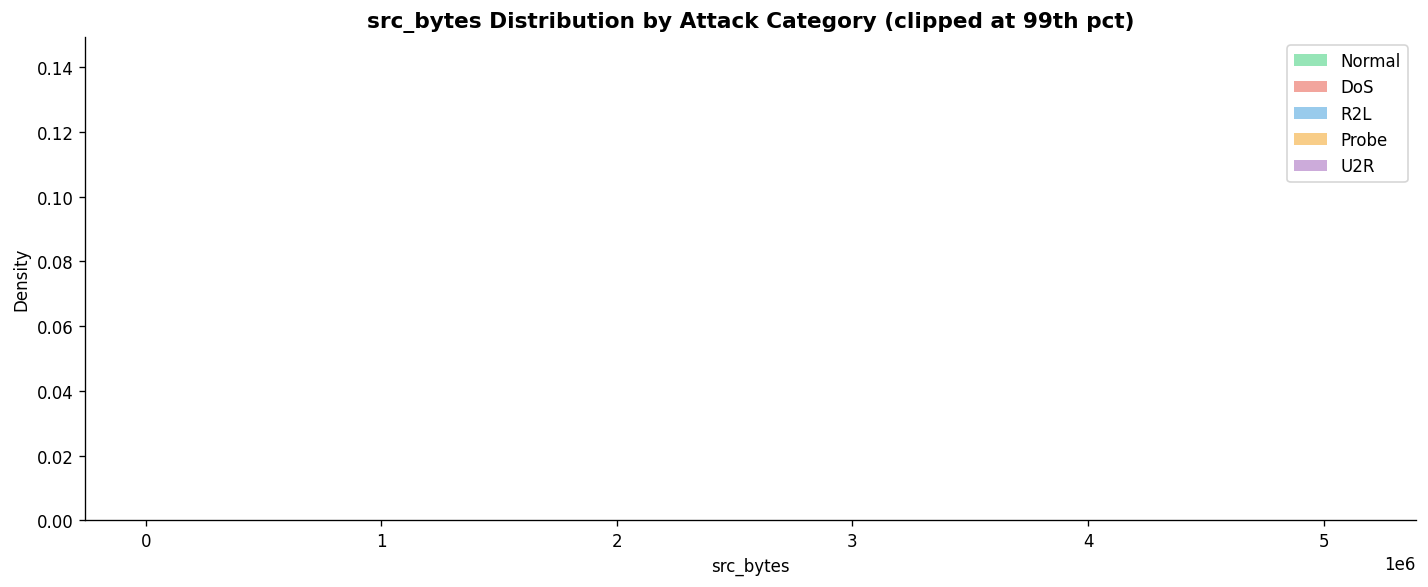

In [18]:
# ── Cell 8: src_bytes distribution by attack category ────
# Ensure 'attack_cat' is defined for plotting purposes if not already present.
# This line is usually in Cell 6, but added here for robustness if cells are run out of order.
if 'attack_cat' not in df.columns:
    df['attack_cat'] = df['label'].str.strip().str.lower().map(ATTACK_MAP).fillna('Other')

fig, ax = plt.subplots(figsize=(12, 5))
for cat, color in zip(df['attack_cat'].unique(), COLORS):
    subset = df[df['attack_cat'] == cat]['src_bytes']
    subset_clipped = subset.clip(upper=subset.quantile(0.99))
    ax.hist(subset_clipped, bins=50, alpha=0.5, label=cat, color=color, density=True)
ax.set_title('src_bytes Distribution by Attack Category (clipped at 99th pct)', fontsize=13, fontweight='bold')
ax.set_xlabel('src_bytes')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing

In [19]:
# ── Cell 9: Preprocessing ────────────────────────────────
df_proc = df.copy()
df_proc.drop(columns=['difficulty'], inplace=True, errors='ignore')
df_proc['label'] = df_proc['label'].str.strip().str.lower()
df_proc['attack_cat'] = df_proc['label'].map(ATTACK_MAP).fillna('Other')

# Encode categorical features
le_dict = {}
for col in CATEGORICAL:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    le_dict[col] = le
    print(f"Encoded '{col}': {list(le.classes_)}")

# Encode target
le_target = LabelEncoder()
df_proc['target'] = le_target.fit_transform(df_proc['attack_cat'])
print(f"\nTarget classes: {dict(enumerate(le_target.classes_))}")

feature_cols = [c for c in df_proc.columns if c not in ['label', 'attack_cat', 'target']]
X = df_proc[feature_cols].astype(float)
y = df_proc['target']
y_cat = df_proc['attack_cat']

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print(f"\nFeatures : {X_scaled.shape[1]}")
print(f"Samples  : {X_scaled.shape[0]}")
print(f"Classes  : {y.nunique()}")


Encoded 'protocol_type': ['icmp', 'tcp', 'udp']
Encoded 'service': ['IRC', 'X11', 'Z39_50', 'aol', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'harvest', 'hostnames', 'http', 'http_2784', 'http_443', 'http_8001', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'login', 'mtp', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'netstat', 'nnsp', 'nntp', 'ntp_u', 'other', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'private', 'red_i', 'remote_job', 'rje', 'shell', 'smtp', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'systat', 'telnet', 'tftp_u', 'tim_i', 'time', 'urh_i', 'urp_i', 'uucp', 'uucp_path', 'vmnet', 'whois']
Encoded 'flag': ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']

Target classes: {0: 'DoS', 1: 'Normal', 2: 'Probe', 3: 'R2L', 4: 'U2R'}

Features : 41
Samples  : 125973
Classes  : 5


In [20]:
# ── Cell 10: Train / Test Split ──────────────────────────
X_train, X_test, y_train, y_test, ycat_train, ycat_test = train_test_split(
    X_scaled, y, y_cat, test_size=0.30, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).map(dict(enumerate(le_target.classes_))).value_counts())


Training set : 88,181 samples
Test set     : 37,792 samples

Class distribution in training set:
target
Normal    47140
DoS       32149
Probe      8159
R2L         697
U2R          36
Name: count, dtype: int64


## Step 5 — Feature Correlation Heatmap

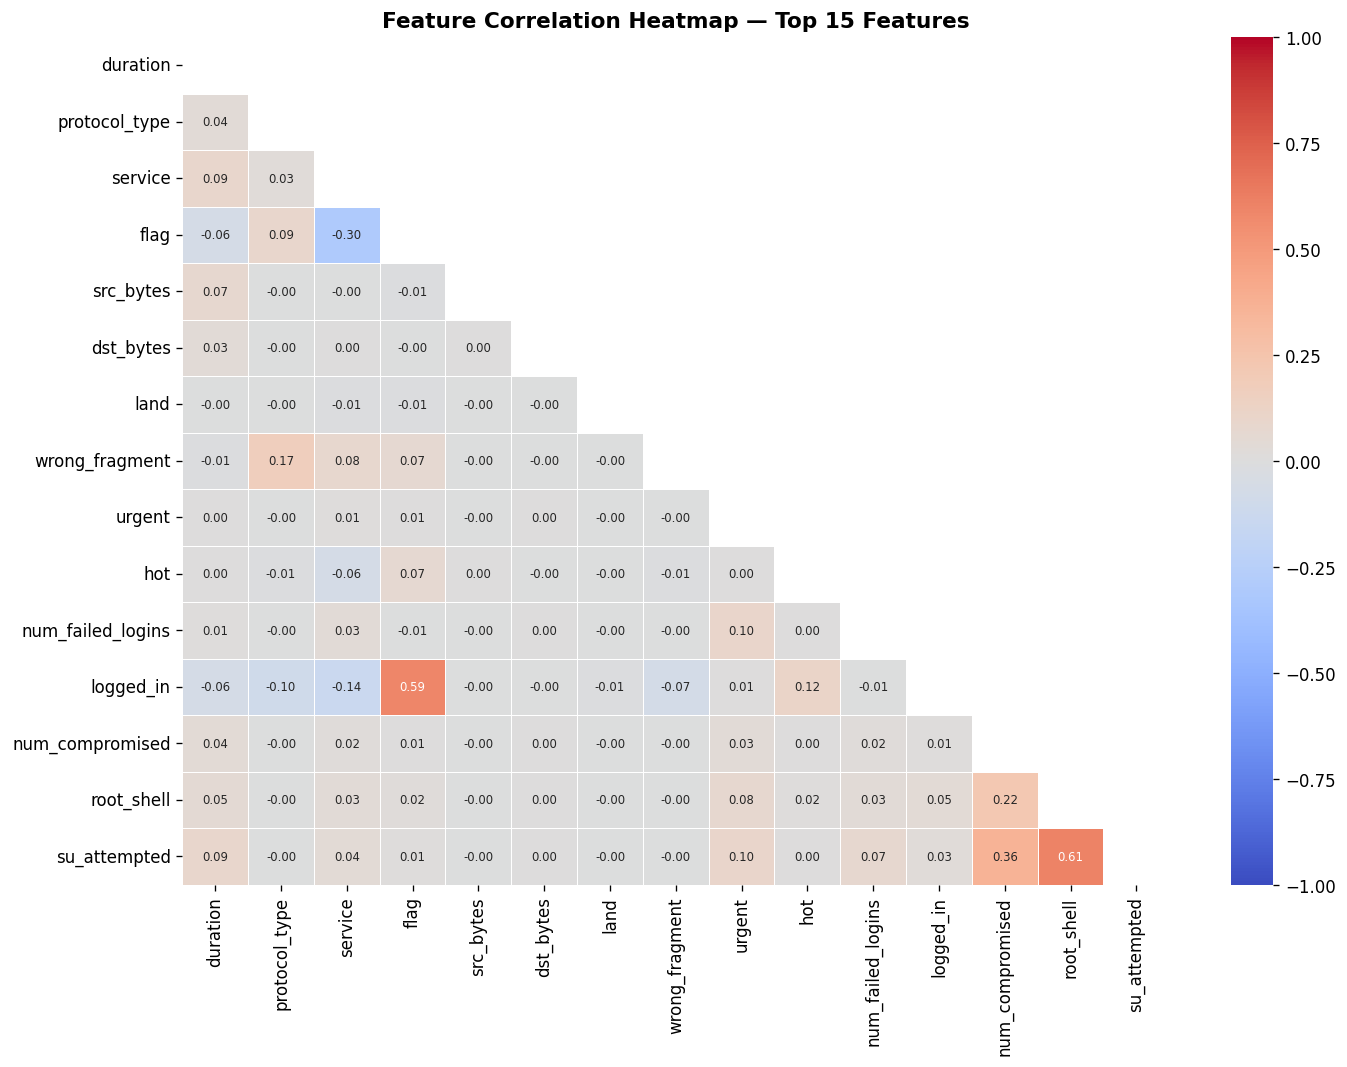

In [21]:
# ── Cell 11: Correlation Heatmap ─────────────────────────
top15 = X_scaled.columns[:15]
corr = X_scaled[top15].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1, center=0)
ax.set_title('Feature Correlation Heatmap — Top 15 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 6 — Model Training & Evaluation

In [22]:
# ── Cell 12: Define All Models ──────────────────────────
models = {
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree':       DecisionTreeClassifier(max_depth=20, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}
print(f"Models to train: {list(models.keys())}")


Models to train: ['Gradient Boosting', 'Random Forest', 'Decision Tree', 'Logistic Regression', 'K-Nearest Neighbors', 'Naive Bayes']


In [23]:
# ── Cell 13: Train & Evaluate All Models ────────────────
results = {}

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'model':    model,
        'accuracy': round(acc * 100, 2),
        'f1':       round(f1  * 100, 2),
        'precision':round(prec* 100, 2),
        'recall':   round(rec * 100, 2),
        'y_pred':   y_pred,
    }
    print(f"Accuracy={acc*100:.2f}%  F1={f1*100:.2f}%")

print("\n✅ All models trained!")


Training Gradient Boosting... Accuracy=99.75%  F1=99.75%
Training Random Forest... Accuracy=99.86%  F1=99.86%
Training Decision Tree... Accuracy=99.76%  F1=99.76%
Training Logistic Regression... Accuracy=96.71%  F1=96.67%
Training K-Nearest Neighbors... Accuracy=99.54%  F1=99.54%
Training Naive Bayes... Accuracy=44.12%  F1=30.73%

✅ All models trained!


In [24]:
# ── Cell 14: Results Summary Table ──────────────────────
summary_df = pd.DataFrame([{
    'Model':         k,
    'Accuracy (%)':  v['accuracy'],
    'F1-Score (%)':  v['f1'],
    'Precision (%)': v['precision'],
    'Recall (%)':    v['recall'],
} for k, v in results.items()]).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print(summary_df.to_string(index=False))
summary_df


              Model  Accuracy (%)  F1-Score (%)  Precision (%)  Recall (%)
      Random Forest         99.86         99.86          99.86       99.86
      Decision Tree         99.76         99.76          99.76       99.76
  Gradient Boosting         99.75         99.75          99.75       99.75
K-Nearest Neighbors         99.54         99.54          99.54       99.54
Logistic Regression         96.71         96.67          96.66       96.71
        Naive Bayes         44.12         30.73          52.49       44.12


,Model,Accuracy (%),F1-Score (%),Precision (%),Recall (%)
0,Random Forest,99.86,99.86,99.86,99.86
1,Decision Tree,99.76,99.76,99.76,99.76
2,Gradient Boosting,99.75,99.75,99.75,99.75
3,K-Nearest Neighbors,99.54,99.54,99.54,99.54
4,Logistic Regression,96.71,96.67,96.66,96.71
5,Naive Bayes,44.12,30.73,52.49,44.12


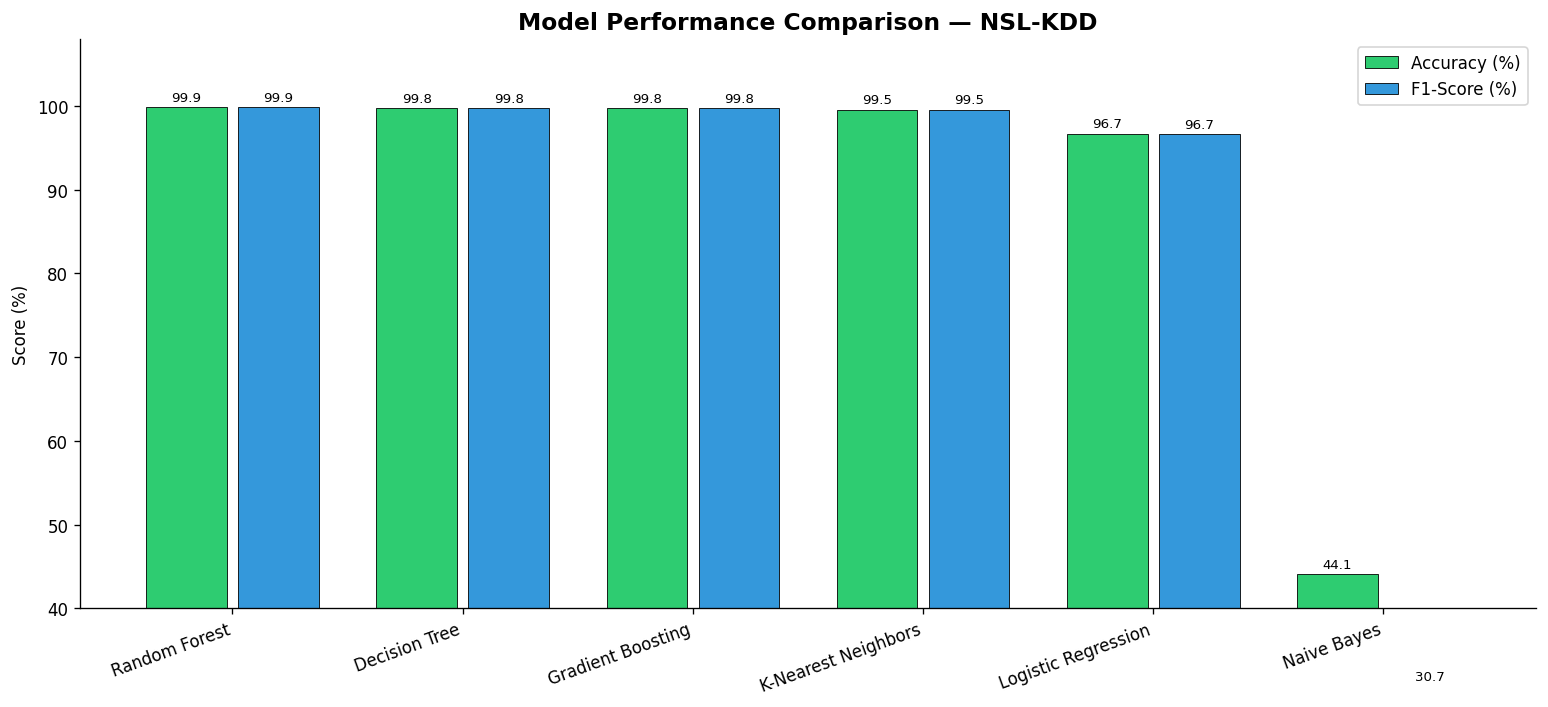

In [25]:
# ── Cell 15: Model Performance Bar Chart ─────────────────
fig, ax = plt.subplots(figsize=(13, 6))
model_names = summary_df['Model'].tolist()
accs = summary_df['Accuracy (%)'].tolist()
f1s  = summary_df['F1-Score (%)'].tolist()
x = np.arange(len(model_names))

bars1 = ax.bar(x - 0.2, accs, 0.35, label='Accuracy (%)', color='#2ecc71', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + 0.2, f1s,  0.35, label='F1-Score (%)', color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(40, 108)
ax.set_title('Model Performance Comparison — NSL-KDD', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## Step 7 — Confusion Matrix (Best Model)

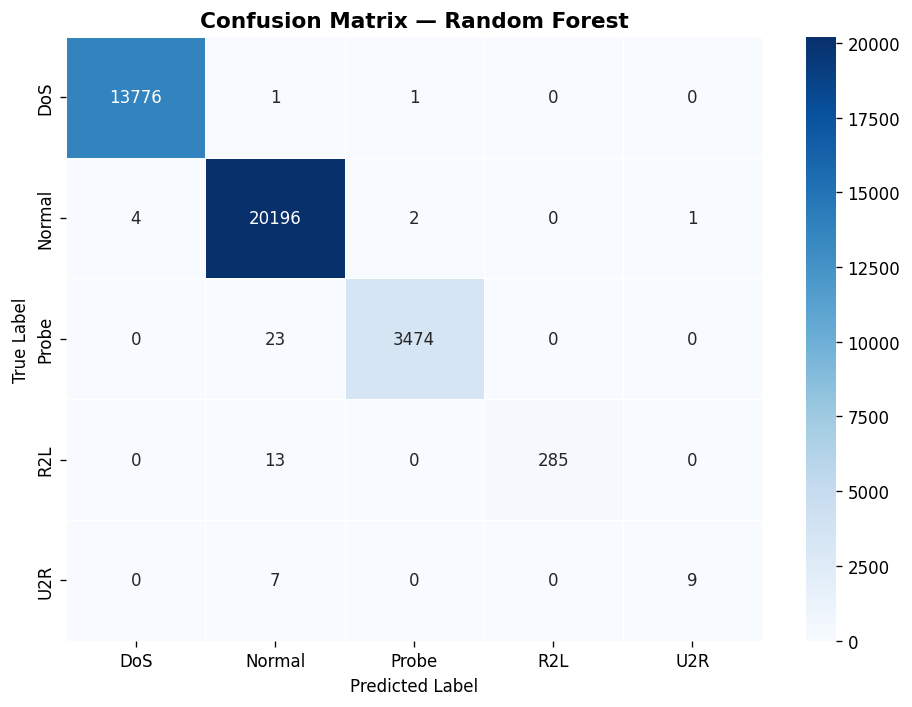


Classification Report — Random Forest:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     13778
      Normal       1.00      1.00      1.00     20203
       Probe       1.00      0.99      1.00      3497
         R2L       1.00      0.96      0.98       298
         U2R       0.90      0.56      0.69        16

    accuracy                           1.00     37792
   macro avg       0.98      0.90      0.93     37792
weighted avg       1.00      1.00      1.00     37792



In [26]:
# ── Cell 16: Confusion Matrix ────────────────────────────
best_name = summary_df.iloc[0]['Model']
best_preds = results[best_name]['y_pred']
class_names = le_target.classes_

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, best_preds, target_names=class_names))


## Step 8 — Feature Importance (Random Forest)

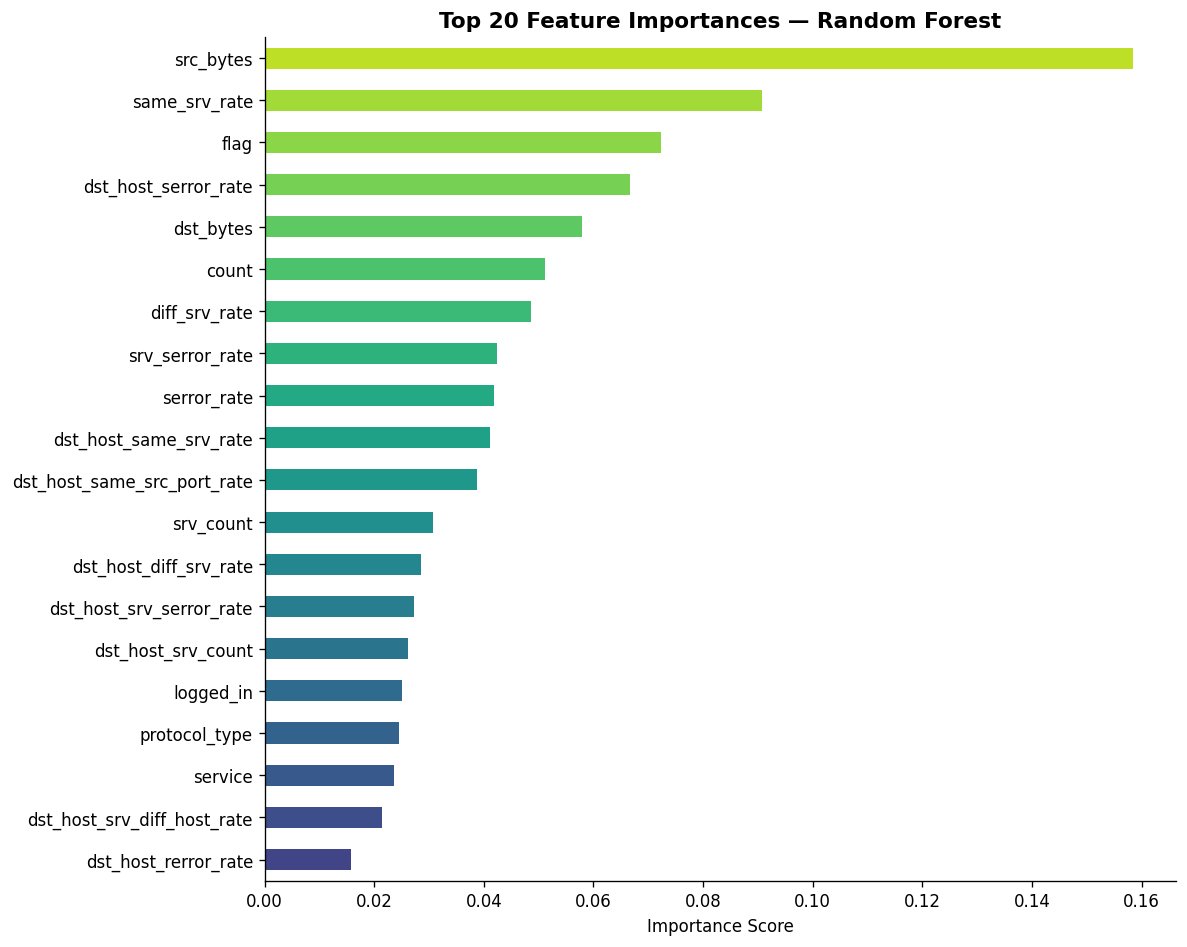


Top 10 most important features:
   1. src_bytes                           0.1584
   2. same_srv_rate                       0.0907
   3. flag                                0.0723
   4. dst_host_serror_rate                0.0667
   5. dst_bytes                           0.0579
   6. count                               0.0512
   7. diff_srv_rate                       0.0486
   8. srv_serror_rate                     0.0424
   9. serror_rate                         0.0418
  10. dst_host_same_srv_rate              0.0411
  11. dst_host_same_src_port_rate         0.0387
  12. srv_count                           0.0307
  13. dst_host_diff_srv_rate              0.0286
  14. dst_host_srv_serror_rate            0.0273
  15. dst_host_srv_count                  0.0262
  16. logged_in                           0.0251
  17. protocol_type                       0.0246
  18. service                             0.0236
  19. dst_host_srv_diff_host_rate         0.0213
  20. dst_host_rerror_rate          

In [27]:
# ── Cell 17: Feature Importance ─────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = plt.cm.viridis(np.linspace(0.2, 0.9, 20))
top20.sort_values().plot(kind='barh', ax=ax, color=colors_imp)
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
for i, (feat, imp) in enumerate(top20.items(), 1):
    print(f"  {i:2d}. {feat:<35} {imp:.4f}")


## Step 9 — Cross-Validation (Best Model)

Model          : Random Forest
CV Scores      : [np.float64(99.88), np.float64(99.83), np.float64(99.91), np.float64(99.9), np.float64(99.89)]
Mean Accuracy  : 99.88%
Std Dev        : ±0.03%


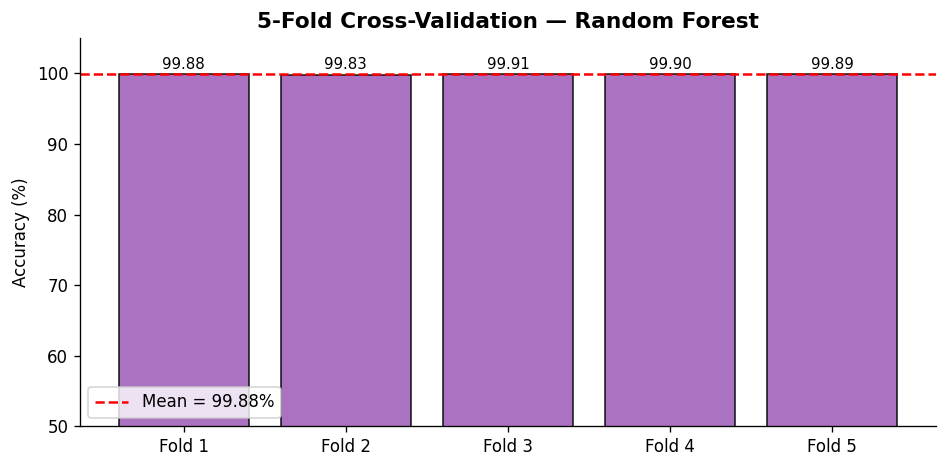

In [28]:
# ── Cell 18: 5-Fold Cross-Validation ────────────────────
best_model = results[best_name]['model']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"Model          : {best_name}")
print(f"CV Scores      : {[round(s*100, 2) for s in cv_scores]}")
print(f"Mean Accuracy  : {cv_scores.mean()*100:.2f}%")
print(f"Std Dev        : ±{cv_scores.std()*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
bars = ax.bar(folds, cv_scores * 100, color='#9b59b6', edgecolor='black', alpha=0.85)
ax.axhline(cv_scores.mean() * 100, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {cv_scores.mean()*100:.2f}%')
ax.set_ylim(50, 105)
ax.set_title(f'5-Fold Cross-Validation — {best_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## Step 10 — Save Results

In [29]:
# ── Cell 19: Save Model Summary CSV ─────────────────────
import os
os.makedirs('outputs', exist_ok=True)
summary_df.to_csv('outputs/model_summary.csv', index=False)
print("✅ Saved: outputs/model_summary.csv")
print(summary_df.to_string(index=False))


✅ Saved: outputs/model_summary.csv
              Model  Accuracy (%)  F1-Score (%)  Precision (%)  Recall (%)
      Random Forest         99.86         99.86          99.86       99.86
      Decision Tree         99.76         99.76          99.76       99.76
  Gradient Boosting         99.75         99.75          99.75       99.75
K-Nearest Neighbors         99.54         99.54          99.54       99.54
Logistic Regression         96.71         96.67          96.66       96.71
        Naive Bayes         44.12         30.73          52.49       44.12


In [30]:
# ── Cell 20: Final Summary ───────────────────────────────
print("=" * 55)
print("  NSL-KDD INTRUSION DETECTION — FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset size   : {len(df):,} records")
print(f"  Features used  : {len(feature_cols)}")
print(f"  Attack classes : {len(le_target.classes_)} ({list(le_target.classes_)})")
print(f"  Train / Test   : {len(X_train):,} / {len(X_test):,}")
print()
print(f"  Best Model     : {best_name}")
print(f"  Accuracy       : {results[best_name]['accuracy']}%")
print(f"  F1-Score       : {results[best_name]['f1']}%")
print(f"  Precision      : {results[best_name]['precision']}%")
print(f"  Recall         : {results[best_name]['recall']}%")
print()
print("  Model Ranking:")
for _, row in summary_df.iterrows():
    print(f"    {row['Model']:<25} Acc={row['Accuracy (%)']:.2f}%  F1={row['F1-Score (%)']:.2f}%")
print("=" * 55)


  NSL-KDD INTRUSION DETECTION — FINAL SUMMARY
  Dataset size   : 125,973 records
  Features used  : 41
  Attack classes : 5 (['DoS', 'Normal', 'Probe', 'R2L', 'U2R'])
  Train / Test   : 88,181 / 37,792

  Best Model     : Random Forest
  Accuracy       : 99.86%
  F1-Score       : 99.86%
  Precision      : 99.86%
  Recall         : 99.86%

  Model Ranking:
    Random Forest             Acc=99.86%  F1=99.86%
    Decision Tree             Acc=99.76%  F1=99.76%
    Gradient Boosting         Acc=99.75%  F1=99.75%
    K-Nearest Neighbors       Acc=99.54%  F1=99.54%
    Logistic Regression       Acc=96.71%  F1=96.67%
    Naive Bayes               Acc=44.12%  F1=30.73%
